---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 15. Autoencoder Baixo Nível

Depois de termos visualizado o funcionamento interno da convolução e do *backpropagation* em modelos simples, passamos agora à construção de uma **rede neuronal real com PyTorch**: um *autoencoder* convolucional.  
O objetivo é compreender como um modelo pode **aprender representações compactas** das imagens de entrada, reconstruindo-as a partir de um vetor latente de dimensão reduzida.

Neste notebook utilizaremos o conjunto de dados **Fashion-MNIST**, composto por imagens 28×28 em tons de cinzento de peças de vestuário.  
O *autoencoder* aprenderá, de forma não supervisionada, a codificar e a reconstruir estas imagens, permitindo observar:
- como o espaço latente captura padrões visuais essenciais;  
- e como o erro de reconstrução orienta o treino por *backpropagation*.

O foco continua a ser didático: compreender o funcionamento interno das camadas, dos gradientes e da reconstrução, mais do que otimizar o desempenho final do modelo.

## 15.1. Preparação do conjunto de dados

Nesta célula configuramos o ambiente PyTorch e preparamos o conjunto de dados que servirá de base ao treino do *autoencoder*.

1. **Importação de bibliotecas**
   - `torch`, `torch.nn` e `torch.optim`: principais módulos da framework PyTorch, responsáveis pelas operações de tensor, definição de redes e algoritmos de otimização.
   - `torchvision.datasets` e `torchvision.transforms`: para descarregar e pré-processar imagens.
   - `matplotlib.pyplot`: para visualização dos resultados.

2. **Configuração do dispositivo**
   - O código verifica automaticamente se existe GPU disponível (`cuda`); caso contrário, recorre à CPU.  
     Este passo garante portabilidade entre máquinas.

3. **Transformação das imagens**
   - Utiliza-se `transforms.ToTensor()` para converter as imagens do Fashion-MNIST em tensores normalizados com valores entre 0 e 1.

4. **Carregamento do dataset**
   - `datasets.FashionMNIST(...)` descarrega e prepara os conjuntos de treino e teste.  
   - `DataLoader` cria lotes (*batches*) de 128 amostras, embaralhando os dados de treino para melhorar a generalização.

5. **Função `show_images()`**
   - Permite visualizar rapidamente um conjunto de imagens do lote, facilitando a inspeção dos dados antes do treino.

Com estes passos, o ambiente está pronto para a definição do modelo *autoencoder*, que será treinado para reconstruir estas imagens a partir de representações latentes comprimidas.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

def show_images(imgs, n=10, title=None):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(imgs[i][0].cpu(), cmap="gray")
        plt.axis("off")
    if title: plt.suptitle(title)
    plt.show()

Device: cpu


## 15.2. Definição do modelo: *Convolutional Autoencoder*

O *autoencoder* é uma rede neuronal que aprende a **comprimir e reconstruir dados**.  
É composto por duas partes simétricas:
- um **encoder**, que transforma a imagem num vetor de dimensão reduzida (*vetor latente*);  
- e um **decoder**, que tenta reconstruir a imagem original a partir dessa representação comprimida.

### 1. Estrutura geral

A classe `ConvAutoencoder` herda de `nn.Module` e define tanto o codificador como o descodificador.

#### **Encoder**
- Recebe imagens 1×28×28 (canal único, escala de cinzentos).  
- Aplica duas convoluções com `stride=2`, que reduzem progressivamente a resolução:
  - 28×28 → 14×14 → 7×7.  
- A cada convolução segue-se uma função de ativação `ReLU`.  
- No final, os *feature maps* são achatados (`Flatten`) e transformados num vetor latente com dimensão configurável (`latent_dim`).

#### **Decoder**
- Reconstrói a imagem a partir do vetor latente.  
- O vetor é primeiro expandido por uma camada linear (`fc_dec`) e reformatado para 32 mapas 7×7.  
- Seguem-se duas camadas de **convolução transposta** (`ConvTranspose2d`), que restauram a resolução:
  - 7×7 → 14×14 → 28×28.  
- A função `Sigmoid` na camada final garante que os valores de saída se mantêm entre 0 e 1, compatíveis com os tensores de entrada.

### 2. Vetor latente

O parâmetro `latent_dim` define a **dimensão do espaço latente**, ou seja, o número de variáveis que codificam cada imagem.  
Neste exemplo usamos `latent_dim=16`, um compromisso entre compressão e fidelidade da reconstrução.

### 3. Fluxo de dados (*forward pass*)

O método `forward()`:
1. Codifica a imagem → $ z = \text{Encoder}(x) \ $;  
2. Reconstroi a imagem → $ \hat{x} = \text{Decoder}(z) \ $;  
3. Devolve tanto a reconstrução como o vetor latente.

### 4. Interpretação didática

Este modelo representa o passo seguinte no percurso iniciado nos notebooks anteriores:
- O **encoder** atua como uma sequência de convoluções e não linearidades, semelhantes às vistas nas CNNs;  
- O **decoder** realiza o processo inverso, aprendendo a reconstruir as imagens a partir das ativações internas;  
- O **vetor latente** funciona como uma representação comprimida — uma espécie de “memória interna” do modelo.

Nos próximos blocos, o modelo será treinado para minimizar a diferença entre a imagem de entrada e a imagem reconstruída, ajustando os pesos de ambas as partes através do *backpropagation*.

In [2]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(True)
        )
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(32*7*7, latent_dim)
        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 32*7*7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        z = self.fc_enc(x)
        x = self.fc_dec(z)
        x = x.view(-1, 32, 7, 7)
        x = self.decoder(x)
        return x, z

model = ConvAutoencoder(latent_dim=16).to(device)
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_enc): Linear(in_features=1568, out_features=16, bias=True)
  (fc_dec): Linear(in_features=16, out_features=1568, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


## 15.3. Treino do autoencoder

Com o modelo definido, passamos agora à fase de **treino**, em que o *autoencoder* aprende a reconstruir as imagens do conjunto Fashion-MNIST.

### 1. Função de perda e otimizador

- **Critério de perda:**  
  Utiliza-se `nn.MSELoss()`, que mede o erro médio quadrático entre a imagem original e a reconstruída:  
$$
  L = \frac{1}{N} \sum_i (x_i - \hat{x}_i)^2
$$
  O objetivo do treino é minimizar esta diferença, incentivando o modelo a reproduzir as entradas com a maior fidelidade possível.

- **Otimizador:**  
  O algoritmo **Adam** (`optim.Adam`) é utilizado para ajustar os pesos.  
  Combina as vantagens da descida do gradiente adaptativa com a acumulação de momentos, proporcionando convergência rápida e estável.  
  A taxa de aprendizagem é fixada em `lr = 0.001`.

### 2. Ciclo de treino

Durante 10 épocas:
1. Coloca-se o modelo em modo de treino (`model.train()`);  
2. Para cada lote (*batch*) de imagens:
   - as imagens são enviadas para o dispositivo (`cuda` ou `cpu`);
   - a perda é calculada entre `outputs` e `imgs`;
   - o gradiente é propagado para trás (`loss.backward()`);  
   - e os pesos são atualizados (`optimizer.step()`).

A perda média por época é armazenada em `train_losses` para posterior visualização.

### 3. Visualização durante o treino

A cada duas épocas, o modelo é colocado em modo de avaliação (`model.eval()`) e reconstrói um conjunto de imagens de teste:
- As primeiras figuras mostram as imagens originais;  
- As seguintes mostram as **reconstruções** produzidas pelo *autoencoder* no mesmo momento do treino.

Esta visualização incremental permite acompanhar a evolução qualitativa:  
à medida que as épocas avançam, as reconstruções tornam-se progressivamente mais nítidas e fiéis às imagens originais.

### 4. Interpretação didática

Este processo traduz o princípio fundamental do *autoencoder*:
- o **encoder** aprende a representar as imagens num espaço latente comprimido,  
- o **decoder** aprende a reconstruir a imagem original a partir dessa representação,  
- e a **perda MSE** fornece o sinal de erro que orienta ambos através do *backpropagation*.

Apesar da sua simplicidade, este treino ilustra todo o ciclo de aprendizagem profunda — da definição de camadas até à atualização automática dos pesos com gradientes calculados de forma diferenciável.

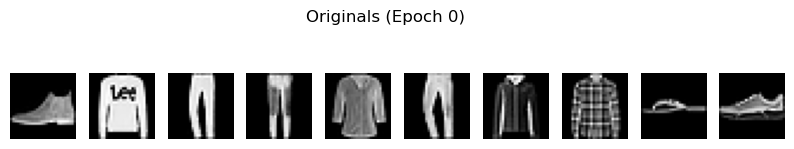

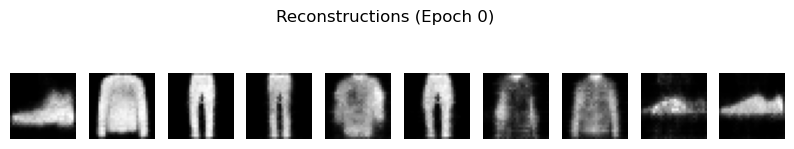

Epoch [1/10], Loss: 0.03900
Epoch [2/10], Loss: 0.01757


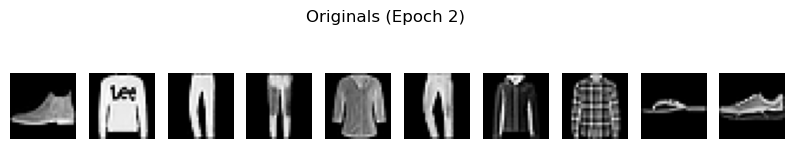

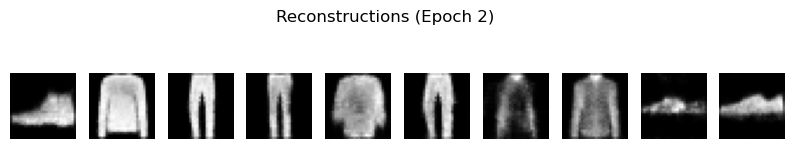

Epoch [3/10], Loss: 0.01575
Epoch [4/10], Loss: 0.01480


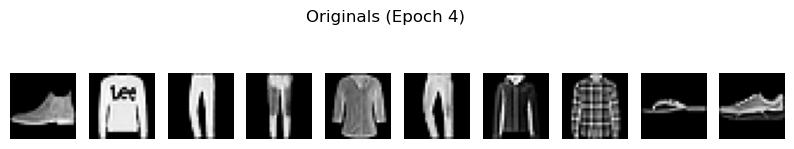

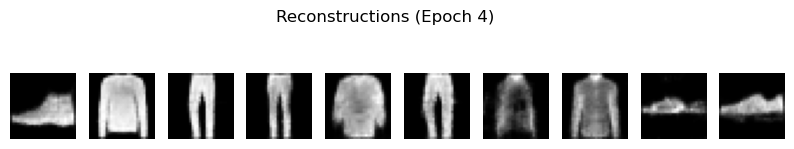

Epoch [5/10], Loss: 0.01419
Epoch [6/10], Loss: 0.01374


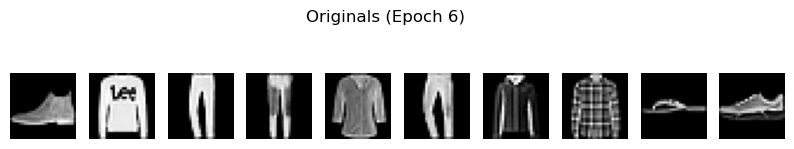

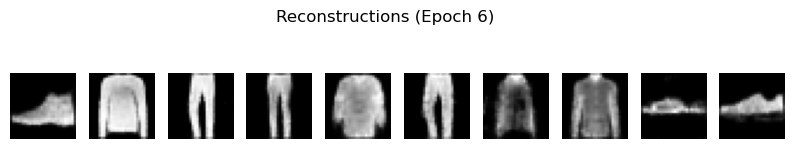

Epoch [7/10], Loss: 0.01340
Epoch [8/10], Loss: 0.01312


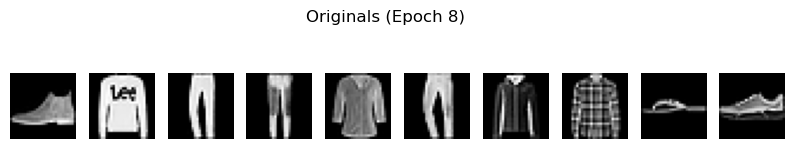

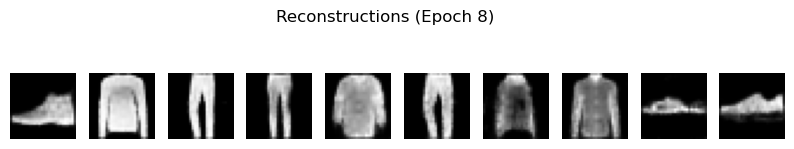

Epoch [9/10], Loss: 0.01289
Epoch [10/10], Loss: 0.01270


In [3]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        outputs, _ = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch % 2 == 0:
        model.eval()
        with torch.no_grad():
            imgs, _ = next(iter(test_loader))
            imgs = imgs.to(device)
            recons, _ = model(imgs)
        show_images(imgs.cpu(), n=10, title=f"Originals (Epoch {epoch})")
        show_images(recons.cpu(), n=10, title=f"Reconstructions (Epoch {epoch})")

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.5f}")

## 15.4. Evolução da perda durante o treino

O gráfico seguinte representa a **curva de perda de treino** (*Training Loss Curve*), ou seja, a evolução do erro médio quadrático (*MSE Loss*) ao longo das épocas.

### 1. Interpretação do gráfico

- O eixo **x** indica o número de épocas (iterações completas sobre o conjunto de treino).  
- O eixo **y** mostra o valor da perda média por época.  
- Cada ponto representa o erro médio de reconstrução obtido após atualizar todos os pesos da rede.

### 2. Tendência esperada

Durante o treino, a perda deve **decrescer gradualmente**, indicando que o modelo está a aprender a reproduzir as imagens de entrada com maior precisão.  
Uma curva suave e monotónica descendente é sinal de convergência estável; oscilações bruscas podem indicar uma taxa de aprendizagem demasiado elevada.

### 3. Valor didático

Este gráfico sintetiza o ciclo de aprendizagem completo:
- o modelo observa as imagens e tenta reconstruí-las;  
- a diferença (perda) é quantificada;  
- os pesos são ajustados em direção a um erro cada vez menor.

Ao contrário dos notebooks anteriores, aqui o *backpropagation* é inteiramente gerido pelo PyTorch —  
mas o princípio matemático é exatamente o mesmo que implementámos manualmente no notebook de *Backpropagation Visualizado*.

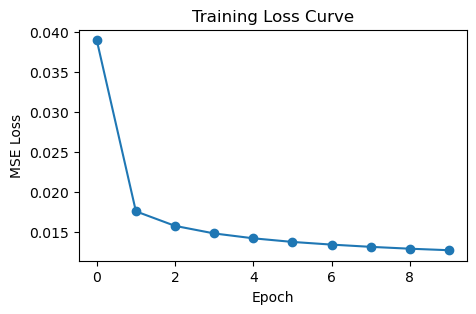

In [4]:
plt.figure(figsize=(5,3))
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

## 15.5. Interpolação no espaço latente

Uma das formas mais elegantes de compreender o funcionamento de um *autoencoder* é observar o que acontece quando se **interpolam vetores latentes** entre duas imagens reais.

### 1. Conceito de espaço latente

Durante o treino, o *encoder* aprendeu a mapear cada imagem para um ponto num espaço contínuo de dimensão reduzida — o **espaço latente**.  
Neste espaço, imagens semelhantes tendem a ficar próximas, e a distância entre pontos reflete variações visuais coerentes (por exemplo, forma, textura, ou tipo de peça de roupa no Fashion-MNIST).

### 2. Interpolação entre duas imagens

Nesta célula:
- são escolhidas duas imagens aleatórias do conjunto de teste (`img_a` e `img_b`);  
- cada uma é codificada no seu vetor latente correspondente (`z_a` e `z_b`);  
- gera-se uma sequência de vetores interpolados entre ambos:
$$
  z(\alpha) = (1 - \alpha) z_a + \alpha z_b, \quad \alpha \in [0, 1]
$$
- cada vetor interpolado é passado pelo *decoder* para reconstruir a imagem correspondente.

O resultado é uma transição suave entre duas imagens reais — como se o modelo “imaginasse” as transformações intermédias necessárias para converter uma peça de roupa noutra.

### 3. Interpretação dos resultados

O conjunto de imagens geradas mostra **uma trajetória contínua** no espaço latente:  
as imagens transformam-se gradualmente, de forma coerente e sem saltos abruptos.  
Isto demonstra que o *autoencoder* aprendeu uma **representação estruturada** do domínio visual,  
onde cada ponto do espaço latente corresponde a uma imagem plausível.

### 4. Valor didático

Esta experiência ilustra de forma tangível o poder dos modelos de codificação:  
o espaço latente não é apenas uma compressão matemática — é uma **organização semântica** das imagens.  
A interpolação mostra que a rede não memoriza exemplos, mas aprende um **espaço de variação contínuo**,  
capaz de gerar combinações novas e coerentes a partir de representações internas.

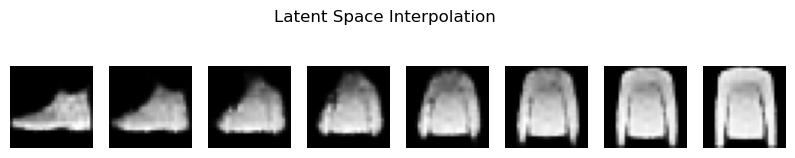

In [7]:
model.eval()
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    img_a, img_b = imgs[0:1], imgs[1:2]
    _, z_a = model(img_a)
    _, z_b = model(img_b)
    n_steps = 8
    interpolations = []
    for alpha in np.linspace(0, 1, n_steps):
        z = (1 - alpha) * z_a + alpha * z_b
        decoded = model.decoder(model.fc_dec(z).view(-1, 32, 7, 7))
        interpolations.append(decoded.cpu())

interpolations = torch.cat(interpolations, dim=0)
show_images(interpolations, n=n_steps, title="Latent Space Interpolation")

## 15.6. Conclusão

Neste notebook construímos e treinámos, passo a passo, um **autoencoder convolucional** capaz de aprender representações latentes de imagens do conjunto Fashion-MNIST.  
Ao longo do processo, observámos como a rede aprende a **comprimir informação visual** e a reconstruí-la de forma progressivamente mais fiel, minimizando o erro de reconstrução através do *backpropagation*.

Foram destacados três aspetos centrais:

1. **Aprendizagem não supervisionada** — o modelo não recebe rótulos nem categorias; aprende apenas a reproduzir as entradas, descobrindo por si próprio as regularidades visuais mais relevantes.  
2. **Espaço latente** — o vetor intermédio aprendido pelo *encoder* constitui uma representação comprimida e contínua, onde imagens semelhantes ocupam regiões próximas.  
3. **Interpretação geométrica** — a interpolação entre vetores latentes demonstrou que o modelo apreende relações estruturais entre as imagens, gerando transições coerentes e visualmente plausíveis.

Do ponto de vista didático, o autoencoder sintetiza os princípios essenciais da aprendizagem profunda:  
as camadas convolucionais que extraem padrões espaciais, as não linearidades que introduzem flexibilidade, e o processo iterativo de otimização que ajusta os pesos até que a reconstrução se torne estável.

Nos próximos capítulos, este mesmo conceito de codificação-descodificação poderá ser estendido a modelos **variacionais** (VAEs) ou a tarefas **condicionadas**,  
onde o espaço latente deixa de ser apenas uma abstração e passa a ser um domínio explorável para geração, manipulação e síntese de novas imagens.